In [1]:
#This notebook uses clustering to segment FinMark customers based on transaction behavior and satisfaction, 
#aiming to identify groups like high-value, frequent, and low-activity customers.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

#clustering
from sklearn.cluster import KMeans

In [28]:
df = pd.read_csv("FinMark_WEEK3_Final.csv")

df.head()

,Customer_ID,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend,Transaction_ID,Transaction_Date,Transaction_Amount,Transaction_Type,FirstTransactionDate,AccountAgeDays,TotalTransactionAmount,TransactionCount
0,1,10.0,Very satisfied,9,29.0,2023-01-02 04:00:00,156.0,Loan Payment,2023-01-02 04:00:00,1120,33672.0,12
1,1,10.0,Very satisfied,9,282.0,2023-01-12 17:00:00,1572.0,Bill Payment,2023-01-02 04:00:00,1120,33672.0,12
2,1,10.0,Very satisfied,9,2883.0,2023-05-01 02:00:00,4867.0,Bill Payment,2023-01-02 04:00:00,1120,33672.0,12
3,1,10.0,Very satisfied,9,3135.0,2023-05-11 14:00:00,1278.0,Investment,2023-01-02 04:00:00,1120,33672.0,12
4,1,10.0,Very satisfied,9,3626.0,2023-06-01 01:00:00,3970.0,Purchase,2023-01-02 04:00:00,1120,33672.0,12


In [31]:
print(df.columns.tolist())

['Customer_ID', 'Satisfaction_Score', 'Feedback_Comments', 'Likelihood_to_Recommend', 'Transaction_ID', 'Transaction_Date', 'Transaction_Amount', 'Transaction_Type', 'FirstTransactionDate', 'AccountAgeDays', 'TotalTransactionAmount', 'TransactionCount']


In [33]:
features = [
    'TotalTransactionAmount',
    'TransactionCount',
    'Satisfaction_Score'
]

X = df[features]
X.head()

,TotalTransactionAmount,TransactionCount,Satisfaction_Score
0,33672.0,12,10.0
1,33672.0,12,10.0
2,33672.0,12,10.0
3,33672.0,12,10.0
4,33672.0,12,10.0


In [35]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[0.01146439, 0.08396947, 0.15254237],
       [0.01146439, 0.08396947, 0.15254237],
       [0.01146439, 0.08396947, 0.15254237],
       [0.01146439, 0.08396947, 0.15254237],
       [0.01146439, 0.08396947, 0.15254237]])

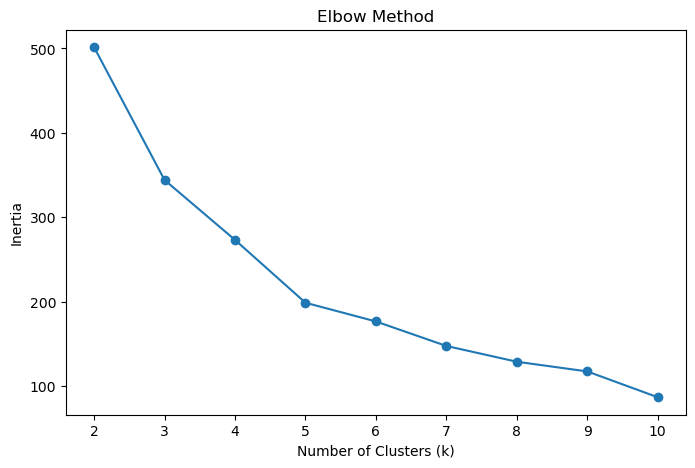

In [37]:
#Elbow Method
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [38]:
#Apply K Means Clustering

k = 4  # change if elbow suggests a different number
kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,Customer_ID,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend,Transaction_ID,Transaction_Date,Transaction_Amount,Transaction_Type,FirstTransactionDate,AccountAgeDays,TotalTransactionAmount,TransactionCount,Cluster
0,1,10.0,Very satisfied,9,29.0,2023-01-02 04:00:00,156.0,Loan Payment,2023-01-02 04:00:00,1120,33672.0,12,0
1,1,10.0,Very satisfied,9,282.0,2023-01-12 17:00:00,1572.0,Bill Payment,2023-01-02 04:00:00,1120,33672.0,12,0
2,1,10.0,Very satisfied,9,2883.0,2023-05-01 02:00:00,4867.0,Bill Payment,2023-01-02 04:00:00,1120,33672.0,12,0
3,1,10.0,Very satisfied,9,3135.0,2023-05-11 14:00:00,1278.0,Investment,2023-01-02 04:00:00,1120,33672.0,12,0
4,1,10.0,Very satisfied,9,3626.0,2023-06-01 01:00:00,3970.0,Purchase,2023-01-02 04:00:00,1120,33672.0,12,0


In [39]:
#Check Cluster Sizes
df['Cluster'].value_counts()

Cluster
0    12924
2    10293
3     1524
1      259
Name: count, dtype: int64

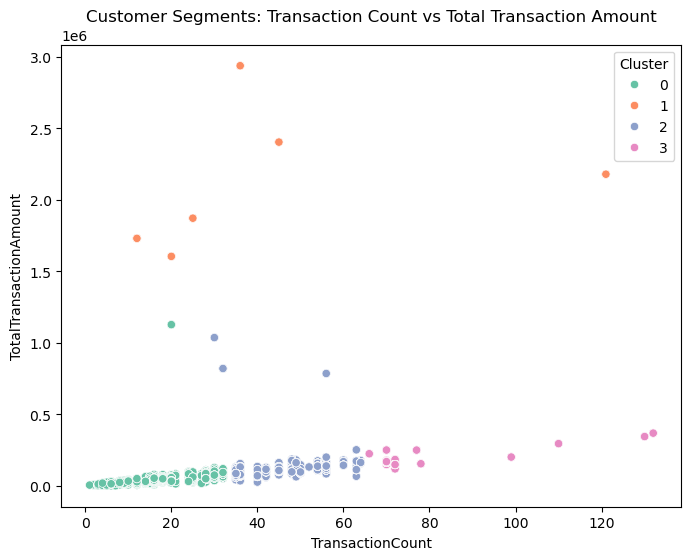

In [40]:
#Visualize Cluster
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='TransactionCount',
    y='TotalTransactionAmount',
    hue='Cluster',
    palette='Set2'
)
plt.title("Customer Segments: Transaction Count vs Total Transaction Amount")
plt.show()

In [41]:
#Analyze Cluster Profiles
cluster_summary = df.groupby('Cluster')[features].mean()
cluster_summary

,TotalTransactionAmount,TransactionCount,Satisfaction_Score
Cluster,,,
0,5.308844e+04,20.747137,5.698550
1,2.228128e+06,73.864865,6.071555
2,1.210291e+05,45.624891,5.621763
3,2.149131e+05,86.568241,6.018658


In [21]:
#### Cluster Interpretation

# Cluster 0: High-value customers with high transaction frequency and high average transaction amount. Likely premium customers.  
# Cluster 1: Customers with frequent transactions but lower spending. May respond well to upselling strategies.  
# Cluster 2: Low-activity customers with low spending and low transaction frequency. May require engagement campaigns.  
# Cluster 3:Customers with moderate spending but high satisfaction. Represent loyal customers.